# HMO Claims & Member Analytics

## Project Overview

This project simulates an HMO analytics environment to examine
member utilization, healthcare claims, provider activity,
claim outcomes, and operational performance.

The dataset is synthetically generated for portfolio and
learning purposes and does not contain real patient or
healthcare provider information.

## Business Questions

1. How many members and claims are in the dataset?
2. How much are healthcare claims costing?
3. Which healthcare services generate the most claims?
4. Which providers have the highest claim volume and claim amount?
5. What percentage of claims are approved, denied, or pending?
6. How long does claim processing take?
7. Which member groups have higher healthcare utilization?
8. What factors appear to be associated with higher claim costs?

## 1. Generate Synthetic HMO Data

The dataset is synthetically generated for portfolio and learning purposes.

It consists of:
- 20,000 HMO members
- 50,000 healthcare claims
- Member demographic and membership information
- Healthcare service and provider information
- Claim amounts, statuses, and processing times

No real patient or healthcare provider information is used.

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Number of members
n_members = 20000

# Create Member IDs
member_ids = [f"M{str(i).zfill(6)}" for i in range(1, n_members + 1)]

# Generate member information
members = pd.DataFrame({
    "Member_ID": member_ids,
    "Age": np.random.randint(18, 71, n_members),
    "Gender": np.random.choice(
        ["Female", "Male"],
        size=n_members,
        p=[0.52, 0.48]
    ),
    "Region": np.random.choice(
        ["NCR", "Luzon", "Visayas", "Mindanao"],
        size=n_members,
        p=[0.35, 0.35, 0.15, 0.15]
    ),
    "Membership_Type": np.random.choice(
        ["Individual", "Corporate", "Family"],
        size=n_members,
        p=[0.30, 0.50, 0.20]
    )
})

# View the first 5 records
members.head()

,Member_ID,Age,Gender,Region,Membership_Type
0,M000001,56,Female,Luzon,Corporate
1,M000002,69,Male,Luzon,Corporate
2,M000003,46,Male,NCR,Corporate
3,M000004,32,Female,NCR,Individual
4,M000005,60,Male,NCR,Corporate


In [ ]:
print("Number of members:", len(members))
print("Number of columns:", members.shape[1])

print("\nMissing values:")
print(members.isna().sum())

Number of members: 20000
Number of columns: 5

Missing values:
Member_ID          0
Age                0
Gender             0
Region             0
Membership_Type    0
dtype: int64


In [ ]:
# Number of claims
n_claims = 50000

# Randomly assign members to claims
claim_member_ids = np.random.choice(
    members["Member_ID"],
    size=n_claims
)

# Claim dates
claim_dates = pd.to_datetime(
    np.random.choice(
        pd.date_range("2025-01-01", "2025-12-31"),
        size=n_claims
    )
)

# Healthcare service types
service_types = np.random.choice(
    [
        "Outpatient",
        "Inpatient",
        "Emergency",
        "Laboratory",
        "Diagnostic",
        "Pharmacy"
    ],
    size=n_claims,
    p=[0.35, 0.12, 0.15, 0.15, 0.13, 0.10]
)

# Healthcare providers
providers = np.random.choice(
    [
        "Provider A",
        "Provider B",
        "Provider C",
        "Provider D",
        "Provider E",
        "Provider F",
        "Provider G",
        "Provider H"
    ],
    size=n_claims
)

# Create claim amounts based on service type
base_amounts = {
    "Outpatient": 1800,
    "Inpatient": 15000,
    "Emergency": 6500,
    "Laboratory": 2200,
    "Diagnostic": 4500,
    "Pharmacy": 1500
}

claim_amount = np.array([
    np.random.lognormal(
        mean=np.log(base_amounts[service]),
        sigma=0.45
    )
    for service in service_types
])

# Round to nearest peso
claim_amount = np.round(claim_amount, 2)

# Claim status
claim_status = np.random.choice(
    ["Approved", "Denied", "Pending"],
    size=n_claims,
    p=[0.88, 0.07, 0.05]
)

# Processing days
processing_days = np.random.randint(1, 11, n_claims)

# Create claims DataFrame
claims = pd.DataFrame({
    "Claim_ID": [
        f"C{str(i).zfill(7)}"
        for i in range(1, n_claims + 1)
    ],
    "Member_ID": claim_member_ids,
    "Claim_Date": claim_dates,
    "Service_Type": service_types,
    "Provider": providers,
    "Claim_Amount": claim_amount,
    "Claim_Status": claim_status,
    "Processing_Days": processing_days
})

claims.head()

,Claim_ID,Member_ID,Claim_Date,Service_Type,Provider,Claim_Amount,Claim_Status,Processing_Days
0,C0000001,M008691,2025-05-22,Outpatient,Provider D,3640.17,Approved,2
1,C0000002,M005656,2025-05-21,Emergency,Provider C,13846.77,Approved,2
2,C0000003,M007794,2025-10-25,Outpatient,Provider H,2436.07,Approved,6
3,C0000004,M015819,2025-08-04,Pharmacy,Provider G,2956.16,Approved,7
4,C0000005,M013920,2025-09-26,Diagnostic,Provider H,6962.64,Approved,6


In [ ]:
print("Number of claims:", len(claims))
print("Number of columns:", claims.shape[1])

print("\nMissing values:")
print(claims.isna().sum())

Number of claims: 50000
Number of columns: 8

Missing values:
Claim_ID           0
Member_ID          0
Claim_Date         0
Service_Type       0
Provider           0
Claim_Amount       0
Claim_Status       0
Processing_Days    0
dtype: int64


In [ ]:
print("MEMBERS DATASET")
print(members.info())

print("\nCLAIMS DATASET")
print(claims.info())

MEMBERS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_ID        20000 non-null  object
 1   Age              20000 non-null  int64 
 2   Gender           20000 non-null  object
 3   Region           20000 non-null  object
 4   Membership_Type  20000 non-null  object
dtypes: int64(1), object(4)
memory usage: 781.4+ KB
None

CLAIMS DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Claim_ID         50000 non-null  object        
 1   Member_ID        50000 non-null  object        
 2   Claim_Date       50000 non-null  datetime64[ns]
 3   Service_Type     50000 non-null  object        
 4   Provider         50000 non-null  object        
 5   Clai

In [ ]:
import os

os.makedirs("/content/hmo_data", exist_ok=True)

members.to_csv(
    "/content/hmo_data/hmo_members.csv",
    index=False
)

claims.to_csv(
    "/content/hmo_data/hmo_claims.csv",
    index=False
)

print("Files saved successfully.")

Files saved successfully.


## 2. Data Quality and Validation

Before conducting the analysis, the member and claims datasets are
checked for completeness, duplicates, valid values, and consistency
between related tables.

In [ ]:
print("MEMBERS DATASET")
print("Rows:", members.shape[0])
print("Columns:", members.shape[1])

print("\nCLAIMS DATASET")
print("Rows:", claims.shape[0])
print("Columns:", claims.shape[1])

MEMBERS DATASET
Rows: 20000
Columns: 5

CLAIMS DATASET
Rows: 50000
Columns: 8


In [ ]:
print("Missing values in MEMBERS:")
print(members.isna().sum())

print("\nMissing values in CLAIMS:")
print(claims.isna().sum())

Missing values in MEMBERS:
Member_ID          0
Age                0
Gender             0
Region             0
Membership_Type    0
dtype: int64

Missing values in CLAIMS:
Claim_ID           0
Member_ID          0
Claim_Date         0
Service_Type       0
Provider           0
Claim_Amount       0
Claim_Status       0
Processing_Days    0
dtype: int64


In [ ]:
print("Duplicate member records:", members.duplicated().sum())
print("Duplicate claim records:", claims.duplicated().sum())

print("\nDuplicate Member IDs:", members["Member_ID"].duplicated().sum())
print("Duplicate Claim IDs:", claims["Claim_ID"].duplicated().sum())

Duplicate member records: 0
Duplicate claim records: 0

Duplicate Member IDs: 0
Duplicate Claim IDs: 0


In [ ]:
print("Minimum age:", members["Age"].min())
print("Maximum age:", members["Age"].max())

Minimum age: 18
Maximum age: 70


In [ ]:
print("\nGender distribution:")
print(members["Gender"].value_counts())


Gender distribution:
Gender
Female    10344
Male       9656
Name: count, dtype: int64


In [14]:
print("\nRegion distribution:")
print(members["Region"].value_counts())


Region distribution:
Region
NCR         7100
Luzon       6970
Mindanao    3012
Visayas     2918
Name: count, dtype: int64


In [15]:
print("\nRegion distribution:")
print(members["Region"].value_counts())


Region distribution:
Region
NCR         7100
Luzon       6970
Mindanao    3012
Visayas     2918
Name: count, dtype: int64


In [16]:
print("Minimum claim amount:", claims["Claim_Amount"].min())
print("Maximum claim amount:", claims["Claim_Amount"].max())
print("Average claim amount:", claims["Claim_Amount"].mean())

Minimum claim amount: 290.14
Maximum claim amount: 77322.71
Average claim amount: 4936.1363354000005


In [18]:
print(
    "Claims with zero or negative amount:",
    (claims["Claim_Amount"] <= 0).sum()
)

Claims with zero or negative amount: 0


In [19]:
print("Claim status distribution:")
print(claims["Claim_Status"].value_counts())

Claim status distribution:
Claim_Status
Approved    44077
Denied       3440
Pending      2483
Name: count, dtype: int64


In [20]:
print("\nService type distribution:")
print(claims["Service_Type"].value_counts())


Service type distribution:
Service_Type
Outpatient    17388
Laboratory     7610
Emergency      7427
Diagnostic     6492
Inpatient      6034
Pharmacy       5049
Name: count, dtype: int64


In [21]:
print("\nProcessing days:")
print("Minimum:", claims["Processing_Days"].min())
print("Maximum:", claims["Processing_Days"].max())


Processing days:
Minimum: 1
Maximum: 10


In [22]:
unknown_members = claims[
    ~claims["Member_ID"].isin(members["Member_ID"])
]

print("Claims linked to unknown members:", len(unknown_members))

Claims linked to unknown members: 0


In [23]:
validation_summary = pd.DataFrame({
    "Check": [
        "Member records",
        "Claim records",
        "Missing member values",
        "Missing claim values",
        "Duplicate member records",
        "Duplicate claim records",
        "Duplicate Member IDs",
        "Duplicate Claim IDs",
        "Invalid claim amounts",
        "Claims linked to unknown members"
    ],
    "Result": [
        len(members),
        len(claims),
        members.isna().sum().sum(),
        claims.isna().sum().sum(),
        members.duplicated().sum(),
        claims.duplicated().sum(),
        members["Member_ID"].duplicated().sum(),
        claims["Claim_ID"].duplicated().sum(),
        (claims["Claim_Amount"] <= 0).sum(),
        len(unknown_members)
    ]
})

validation_summary

,Check,Result
0,Member records,20000
1,Claim records,50000
2,Missing member values,0
3,Missing claim values,0
4,Duplicate member records,0
5,Duplicate claim records,0
6,Duplicate Member IDs,0
7,Duplicate Claim IDs,0
8,Invalid claim amounts,0
9,Claims linked to unknown members,0


## 3. Key HMO Performance Indicators

The following indicators provide a high-level overview of member enrollment,
healthcare claim activity, claim costs, claim outcomes, and operational
processing performance.

In [24]:
# Basic HMO KPIs

total_members = members["Member_ID"].nunique()

total_claims = claims["Claim_ID"].nunique()

total_claim_amount = claims["Claim_Amount"].sum()

average_claim_amount = claims["Claim_Amount"].mean()

average_processing_days = claims["Processing_Days"].mean()

print("Total Members:", f"{total_members:,}")
print("Total Claims:", f"{total_claims:,}")
print("Total Claim Amount:", f"₱{total_claim_amount:,.2f}")
print("Average Claim Amount:", f"₱{average_claim_amount:,.2f}")
print("Average Processing Days:", f"{average_processing_days:.2f}")

Total Members: 20,000
Total Claims: 50,000
Total Claim Amount: ₱246,806,816.77
Average Claim Amount: ₱4,936.14
Average Processing Days: 5.50


In [25]:
approved_claims = (
    claims["Claim_Status"] == "Approved"
).sum()

denied_claims = (
    claims["Claim_Status"] == "Denied"
).sum()

pending_claims = (
    claims["Claim_Status"] == "Pending"
).sum()

approval_rate = approved_claims / total_claims * 100

denial_rate = denied_claims / total_claims * 100

pending_rate = pending_claims / total_claims * 100

print("Approved Claims:", f"{approved_claims:,}")
print("Denied Claims:", f"{denied_claims:,}")
print("Pending Claims:", f"{pending_claims:,}")

print("\nApproval Rate:", f"{approval_rate:.2f}%")
print("Denial Rate:", f"{denial_rate:.2f}%")
print("Pending Rate:", f"{pending_rate:.2f}%")

Approved Claims: 44,077
Denied Claims: 3,440
Pending Claims: 2,483

Approval Rate: 88.15%
Denial Rate: 6.88%
Pending Rate: 4.97%


In [26]:
members_with_claims = claims["Member_ID"].nunique()

utilization_rate = (
    members_with_claims / total_members
) * 100

print("Members with claims:", f"{members_with_claims:,}")
print("Member utilization rate:", f"{utilization_rate:.2f}%")

Members with claims: 18,384
Member utilization rate: 91.92%


In [27]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Members",
        "Total Claims",
        "Total Claim Amount",
        "Average Claim Amount",
        "Approved Claims",
        "Approval Rate",
        "Denied Claims",
        "Denial Rate",
        "Pending Claims",
        "Pending Rate",
        "Members With Claims",
        "Member Utilization Rate",
        "Average Processing Days"
    ],
    "Value": [
        total_members,
        total_claims,
        total_claim_amount,
        average_claim_amount,
        approved_claims,
        approval_rate,
        denied_claims,
        denial_rate,
        pending_claims,
        pending_rate,
        members_with_claims,
        utilization_rate,
        average_processing_days
    ]
})

kpi_summary

,KPI,Value
0,Total Members,2.000000e+04
1,Total Claims,5.000000e+04
2,Total Claim Amount,2.468068e+08
3,Average Claim Amount,4.936136e+03
4,Approved Claims,4.407700e+04
5,Approval Rate,8.815400e+01
6,Denied Claims,3.440000e+03
7,Denial Rate,6.880000e+00
8,Pending Claims,2.483000e+03
9,Pending Rate,4.966000e+00


In [28]:
claims_by_status = (
    claims
    .groupby("Claim_Status")
    .agg(
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean")
    )
    .reset_index()
)

claims_by_status

,Claim_Status,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,Approved,44077,2.178731e+08,4943.010733
1,Denied,3440,1.725648e+07,5016.417334
2,Pending,2483,1.167726e+07,4702.882429


## 4. Claims Trend Analysis

This analysis examines monthly claim volume, total claim costs,
and average claim amounts to identify changes in healthcare
utilization and claim spending over time.

In [29]:
# Create a monthly period variable
claims["Claim_Month"] = claims["Claim_Date"].dt.to_period("M")

claims[["Claim_Date", "Claim_Month"]].head()

,Claim_Date,Claim_Month
0,2025-05-22,2025-05
1,2025-05-21,2025-05
2,2025-10-25,2025-10
3,2025-08-04,2025-08
4,2025-09-26,2025-09


In [30]:
monthly_claims = (
    claims
    .groupby("Claim_Month")
    .agg(
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean")
    )
    .reset_index()
)

monthly_claims

,Claim_Month,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,2025-01,4276,20793750.73,4862.897739
1,2025-02,3808,18471197.20,4850.629517
2,2025-03,4212,20652212.50,4903.184354
3,2025-04,4126,20839071.54,5050.671726
4,2025-05,4230,20872340.13,4934.359369
5,2025-06,4120,19900944.68,4830.326379
6,2025-07,4272,20960118.75,4906.394838
7,2025-08,4292,21129520.03,4923.000939
8,2025-09,4077,20050096.20,4917.855335
9,2025-10,4270,21667698.41,5074.402438


In [32]:
monthly_claims["Month"] = (
    monthly_claims["Claim_Month"]
    .dt.strftime("%b %Y")
)

monthly_claims

,Claim_Month,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Month
0,2025-01,4276,20793750.73,4862.897739,Jan 2025
1,2025-02,3808,18471197.20,4850.629517,Feb 2025
2,2025-03,4212,20652212.50,4903.184354,Mar 2025
3,2025-04,4126,20839071.54,5050.671726,Apr 2025
4,2025-05,4230,20872340.13,4934.359369,May 2025
5,2025-06,4120,19900944.68,4830.326379,Jun 2025
6,2025-07,4272,20960118.75,4906.394838,Jul 2025
7,2025-08,4292,21129520.03,4923.000939,Aug 2025
8,2025-09,4077,20050096.20,4917.855335,Sep 2025
9,2025-10,4270,21667698.41,5074.402438,Oct 2025


In [33]:
highest_claim_volume = monthly_claims.loc[
    monthly_claims["Claim_Count"].idxmax()
]

print("Month with highest claim volume:")
print(highest_claim_volume)

Month with highest claim volume:
Claim_Month                 2025-08
Claim_Count                    4292
Total_Claim_Amount      21129520.03
Average_Claim_Amount    4923.000939
Month                      Aug 2025
Name: 7, dtype: object


In [34]:
lowest_claim_volume = monthly_claims.loc[
    monthly_claims["Claim_Count"].idxmin()
]

print("Month with lowest claim volume:")
print(lowest_claim_volume)

Month with lowest claim volume:
Claim_Month                 2025-02
Claim_Count                    3808
Total_Claim_Amount       18471197.2
Average_Claim_Amount    4850.629517
Month                      Feb 2025
Name: 1, dtype: object


In [35]:
highest_claim_cost = monthly_claims.loc[
    monthly_claims["Total_Claim_Amount"].idxmax()
]

print("Month with highest claim spending:")
print(highest_claim_cost)

Month with highest claim spending:
Claim_Month                 2025-10
Claim_Count                    4270
Total_Claim_Amount      21667698.41
Average_Claim_Amount    5074.402438
Month                      Oct 2025
Name: 9, dtype: object


In [36]:
lowest_claim_cost = monthly_claims.loc[
    monthly_claims["Total_Claim_Amount"].idxmin()
]

print("Month with lowest claim spending:")
print(lowest_claim_cost)

Month with lowest claim spending:
Claim_Month                 2025-02
Claim_Count                    3808
Total_Claim_Amount       18471197.2
Average_Claim_Amount    4850.629517
Month                      Feb 2025
Name: 1, dtype: object


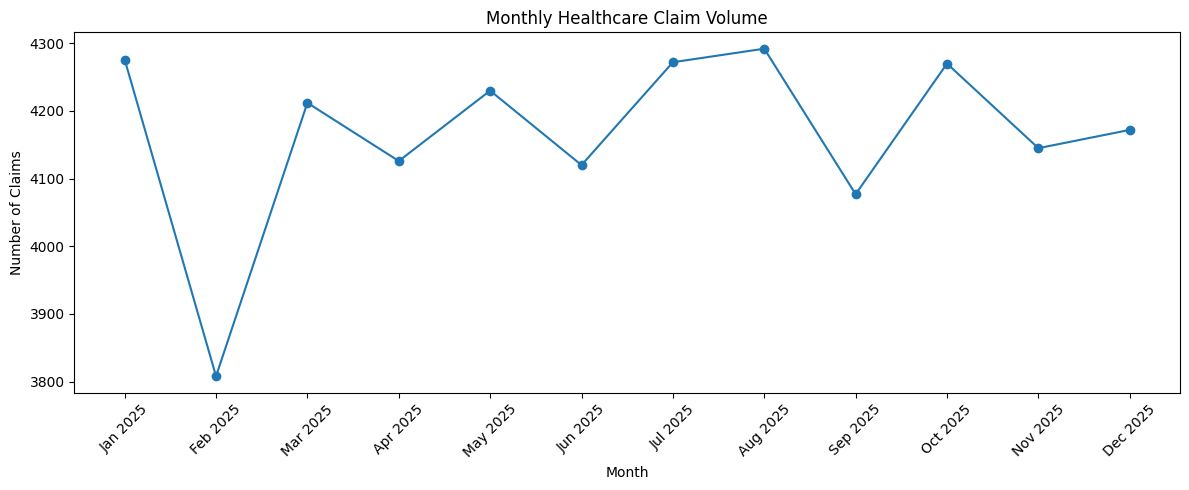

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_claims["Month"],
    monthly_claims["Claim_Count"],
    marker="o"
)

plt.title("Monthly Healthcare Claim Volume")
plt.xlabel("Month")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

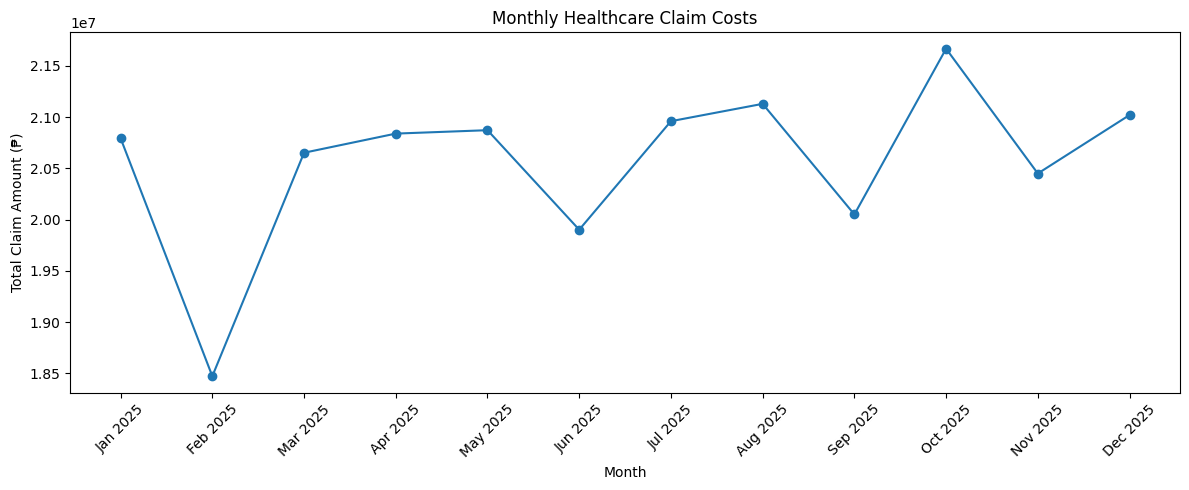

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_claims["Month"],
    monthly_claims["Total_Claim_Amount"],
    marker="o"
)

plt.title("Monthly Healthcare Claim Costs")
plt.xlabel("Month")
plt.ylabel("Total Claim Amount (₱)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

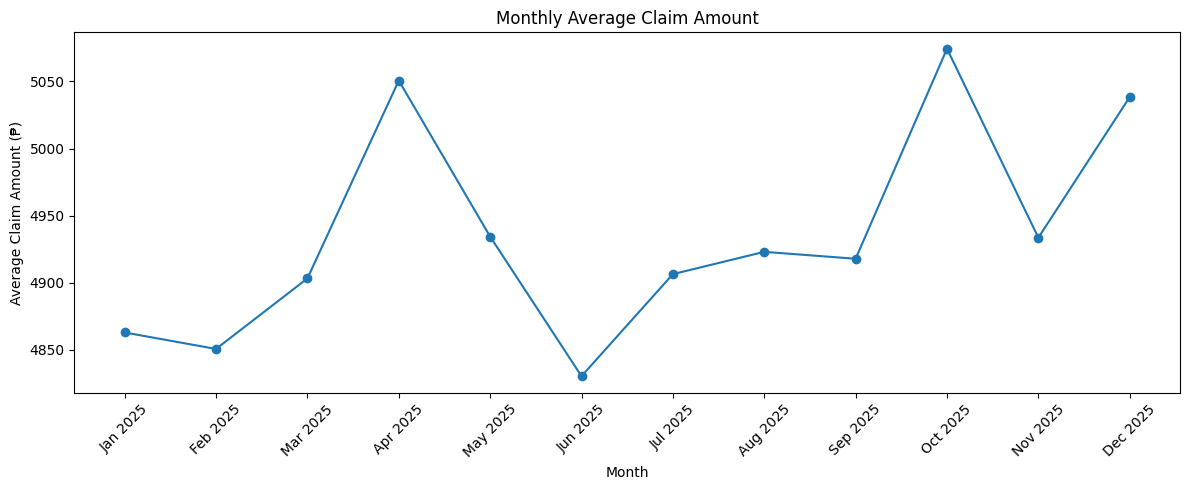

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_claims["Month"],
    monthly_claims["Average_Claim_Amount"],
    marker="o"
)

plt.title("Monthly Average Claim Amount")
plt.xlabel("Month")
plt.ylabel("Average Claim Amount (₱)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Key Findings

- Monthly claim volume fluctuated throughout 2025, ranging from 3,808 claims in February to 4,292 claims in August.
- February recorded the lowest total claim amount at approximately ₱18.47 million, while October recorded the highest at approximately ₱21.67 million.
- October also recorded the highest average claim amount at approximately ₱5,074, while June recorded the lowest at approximately ₱4,830.
- The month with the highest claim volume was not the same as the month with the highest claim spending. August had the highest number of claims, while October had the highest total and average claim amounts.
- These results demonstrate the importance of examining both claim volume and claim value when monitoring HMO utilization and healthcare costs.

## 5. Service Type Analysis

Healthcare claims are categorized into different service types to examine
differences in utilization and healthcare spending.

This analysis compares:
- Claim volume by service type
- Total claim amount by service type
- Average claim amount by service type
- Share of total claim costs by service type

The analysis helps identify which healthcare services contribute most to
overall claim activity and spending.

In [40]:
service_analysis = (
    claims
    .groupby("Service_Type")
    .agg(
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean")
    )
    .reset_index()
)

service_analysis

,Service_Type,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,Diagnostic,6492,32423103.67,4994.316647
1,Emergency,7427,53254579.22,7170.402480
2,Inpatient,6034,99641122.21,16513.278457
3,Laboratory,7610,18474449.95,2427.654396
4,Outpatient,17388,34630629.36,1991.639600
5,Pharmacy,5049,8382932.36,1660.315381


In [41]:
service_analysis["Cost_Share"] = (
    service_analysis["Total_Claim_Amount"]
    / service_analysis["Total_Claim_Amount"].sum()
    * 100
)

service_analysis = service_analysis.sort_values(
    "Total_Claim_Amount",
    ascending=False
)

service_analysis

,Service_Type,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Cost_Share
2,Inpatient,6034,99641122.21,16513.278457,40.372111
1,Emergency,7427,53254579.22,7170.402480,21.577434
4,Outpatient,17388,34630629.36,1991.639600,14.031472
0,Diagnostic,6492,32423103.67,4994.316647,13.137037
3,Laboratory,7610,18474449.95,2427.654396,7.485389
5,Pharmacy,5049,8382932.36,1660.315381,3.396556


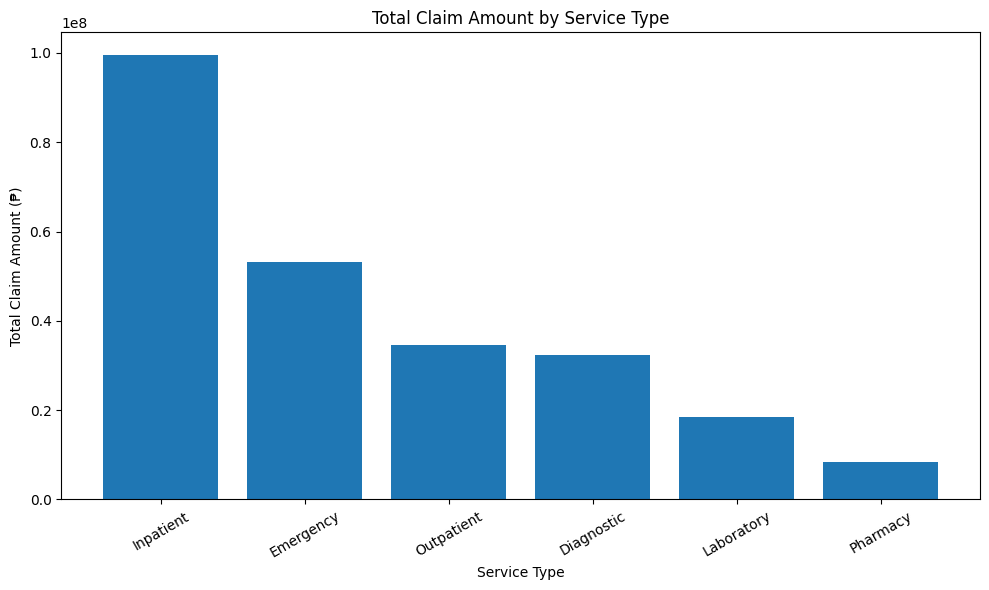

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(
    service_analysis["Service_Type"],
    service_analysis["Total_Claim_Amount"]
)

plt.title("Total Claim Amount by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Total Claim Amount (₱)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

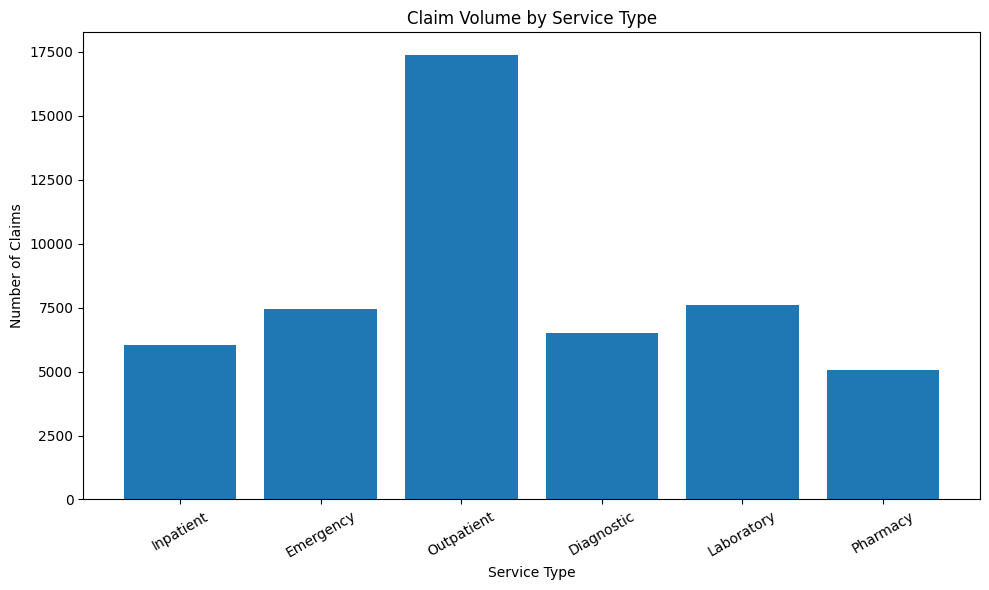

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    service_analysis["Service_Type"],
    service_analysis["Claim_Count"]
)

plt.title("Claim Volume by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Number of Claims")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

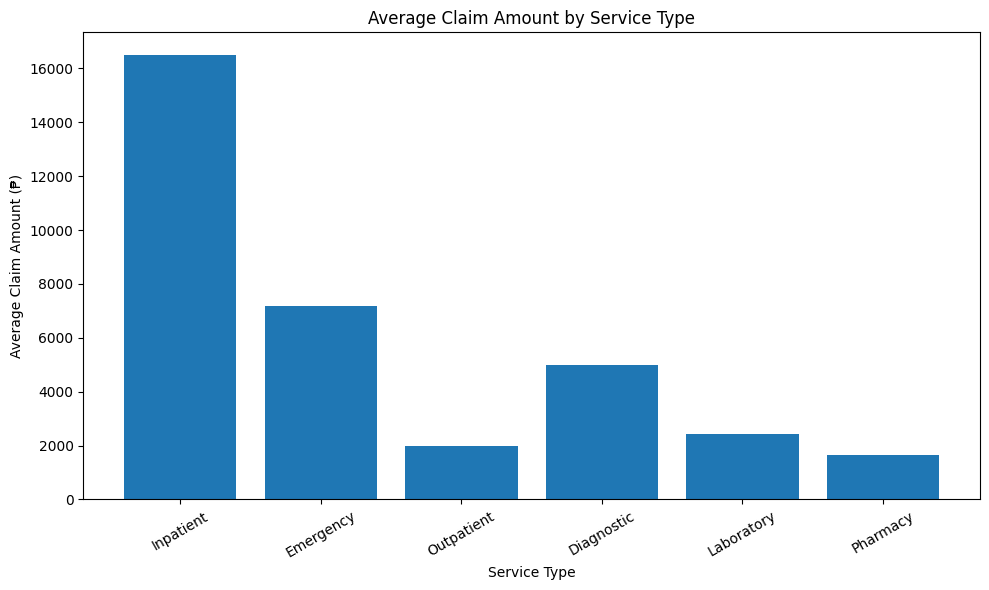

In [44]:
plt.figure(figsize=(10, 6))

plt.bar(
    service_analysis["Service_Type"],
    service_analysis["Average_Claim_Amount"]
)

plt.title("Average Claim Amount by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Claim Amount (₱)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [45]:
service_display = service_analysis.copy()

service_display["Total_Claim_Amount"] = (
    service_display["Total_Claim_Amount"]
    .map(lambda x: f"₱{x:,.2f}")
)

service_display["Average_Claim_Amount"] = (
    service_display["Average_Claim_Amount"]
    .map(lambda x: f"₱{x:,.2f}")
)

service_display["Cost_Share"] = (
    service_display["Cost_Share"]
    .map(lambda x: f"{x:.2f}%")
)

service_display

,Service_Type,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Cost_Share
2,Inpatient,6034,"₱99,641,122.21","₱16,513.28",40.37%
1,Emergency,7427,"₱53,254,579.22","₱7,170.40",21.58%
4,Outpatient,17388,"₱34,630,629.36","₱1,991.64",14.03%
0,Diagnostic,6492,"₱32,423,103.67","₱4,994.32",13.14%
3,Laboratory,7610,"₱18,474,449.95","₱2,427.65",7.49%
5,Pharmacy,5049,"₱8,382,932.36","₱1,660.32",3.40%


### Key Findings

- Outpatient services generated the highest claim volume, with 17,388 claims, representing the most frequently used service type in the dataset.
- Inpatient services accounted for the largest share of total claim costs at 40.37%, despite having substantially fewer claims than outpatient services.
- Inpatient claims had the highest average claim amount at ₱16,513.28, compared with ₱1,991.64 for outpatient claims.
- Emergency services were the second-largest contributor to total claim costs, accounting for 21.58% of overall claim spending.
- The results demonstrate that claim frequency and financial impact can differ substantially. High-volume services are not necessarily the largest drivers of healthcare expenditure.

### Business Implication

From an HMO analytics perspective, monitoring claim volume alone may not
provide a complete picture of healthcare costs. High-cost service categories,
particularly inpatient and emergency services, should be examined alongside
utilization to better understand their contribution to overall claim spending.

## 6. Provider Performance Analysis

This analysis compares healthcare providers based on claim volume,
total claim spending, average claim amount, processing time, and
claim approval rate.

The objective is to identify differences in provider activity and
operational performance and to determine which providers contribute
most to overall claim volume and spending.

In [46]:
provider_analysis = (
    claims
    .groupby("Provider")
    .agg(
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean"),
        Average_Processing_Days=("Processing_Days", "mean")
    )
    .reset_index()
)

provider_analysis

,Provider,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Processing_Days
0,Provider A,6321,31624858.40,5003.141655,5.482519
1,Provider B,6247,31197153.37,4993.941631,5.484393
2,Provider C,6285,30450126.01,4844.888784,5.482578
3,Provider D,6114,30343118.80,4962.891528,5.493294
4,Provider E,6219,30685718.87,4934.188595,5.466474
5,Provider F,6170,30404083.61,4927.728300,5.490113
6,Provider G,6249,31153715.94,4985.392213,5.538486
7,Provider H,6395,30948041.77,4839.412317,5.538858


In [47]:
provider_approval = (
    claims
    .assign(
        Approved_Flag=(
            claims["Claim_Status"] == "Approved"
        ).astype(int)
    )
    .groupby("Provider")
    .agg(
        Approval_Rate=("Approved_Flag", "mean")
    )
    .reset_index()
)

provider_approval["Approval_Rate"] = (
    provider_approval["Approval_Rate"] * 100
)

provider_approval

,Provider,Approval_Rate
0,Provider A,87.755102
1,Provider B,88.106291
2,Provider C,88.353222
3,Provider D,88.092902
4,Provider E,88.535134
5,Provider F,88.330632
6,Provider G,87.902064
7,Provider H,88.162627


In [48]:
provider_analysis = provider_analysis.merge(
    provider_approval,
    on="Provider",
    how="left"
)

provider_analysis

,Provider,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Processing_Days,Approval_Rate
0,Provider A,6321,31624858.40,5003.141655,5.482519,87.755102
1,Provider B,6247,31197153.37,4993.941631,5.484393,88.106291
2,Provider C,6285,30450126.01,4844.888784,5.482578,88.353222
3,Provider D,6114,30343118.80,4962.891528,5.493294,88.092902
4,Provider E,6219,30685718.87,4934.188595,5.466474,88.535134
5,Provider F,6170,30404083.61,4927.728300,5.490113,88.330632
6,Provider G,6249,31153715.94,4985.392213,5.538486,87.902064
7,Provider H,6395,30948041.77,4839.412317,5.538858,88.162627


In [49]:
provider_by_cost = provider_analysis.sort_values(
    "Total_Claim_Amount",
    ascending=False
)

provider_by_cost

,Provider,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Processing_Days,Approval_Rate
0,Provider A,6321,31624858.40,5003.141655,5.482519,87.755102
1,Provider B,6247,31197153.37,4993.941631,5.484393,88.106291
6,Provider G,6249,31153715.94,4985.392213,5.538486,87.902064
7,Provider H,6395,30948041.77,4839.412317,5.538858,88.162627
4,Provider E,6219,30685718.87,4934.188595,5.466474,88.535134
2,Provider C,6285,30450126.01,4844.888784,5.482578,88.353222
5,Provider F,6170,30404083.61,4927.728300,5.490113,88.330632
3,Provider D,6114,30343118.80,4962.891528,5.493294,88.092902


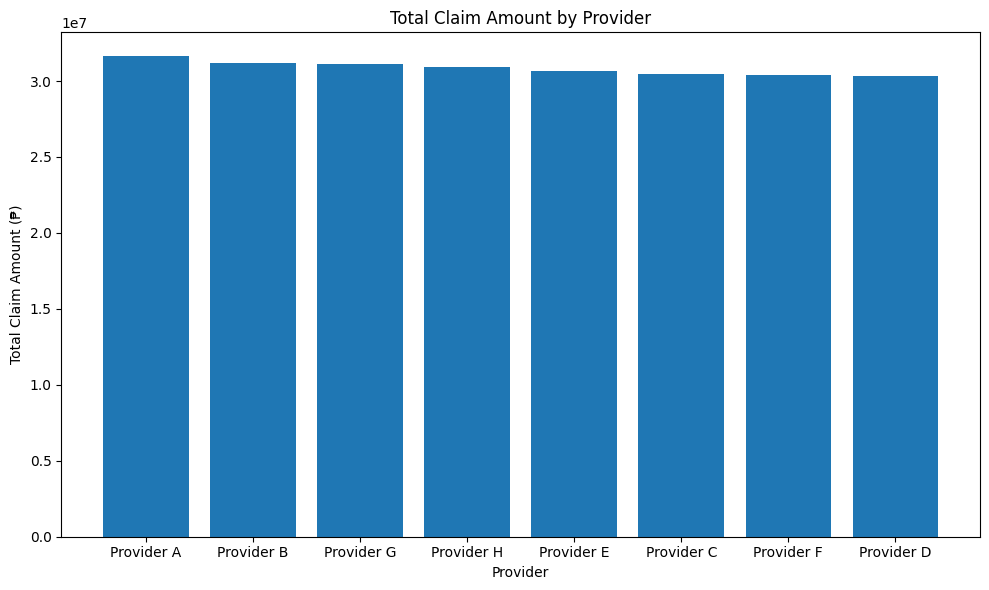

In [50]:
plt.figure(figsize=(10, 6))

plt.bar(
    provider_by_cost["Provider"],
    provider_by_cost["Total_Claim_Amount"]
)

plt.title("Total Claim Amount by Provider")
plt.xlabel("Provider")
plt.ylabel("Total Claim Amount (₱)")

plt.tight_layout()
plt.show()

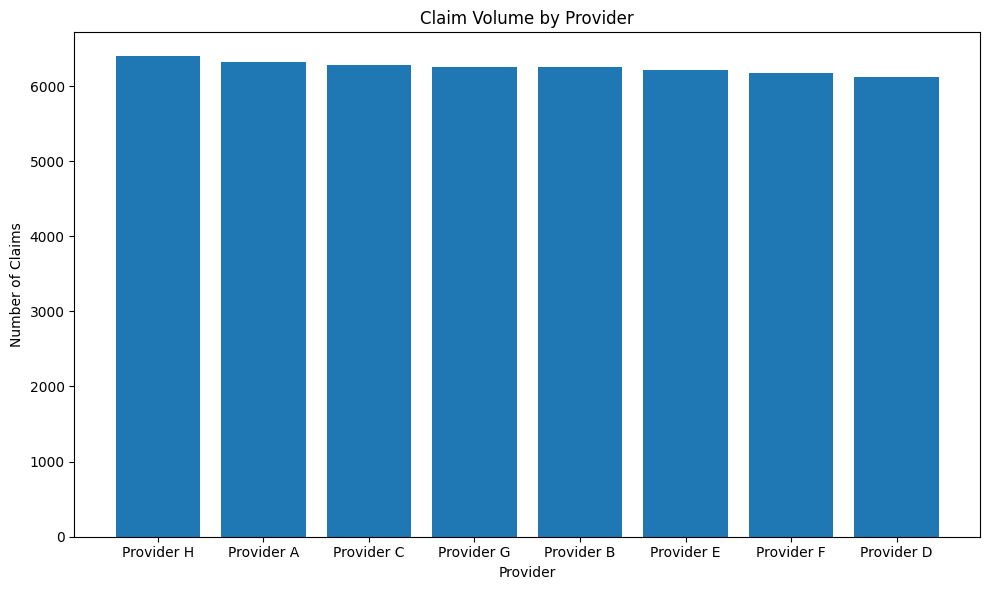

In [51]:
provider_by_volume = provider_analysis.sort_values(
    "Claim_Count",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    provider_by_volume["Provider"],
    provider_by_volume["Claim_Count"]
)

plt.title("Claim Volume by Provider")
plt.xlabel("Provider")
plt.ylabel("Number of Claims")

plt.tight_layout()
plt.show()

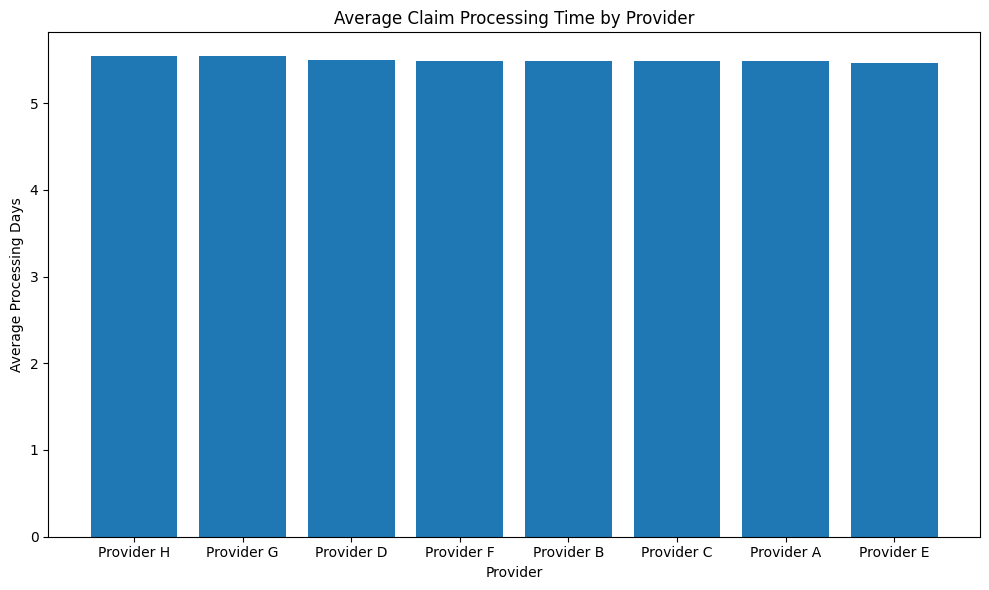

In [52]:
provider_by_processing = provider_analysis.sort_values(
    "Average_Processing_Days",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    provider_by_processing["Provider"],
    provider_by_processing["Average_Processing_Days"]
)

plt.title("Average Claim Processing Time by Provider")
plt.xlabel("Provider")
plt.ylabel("Average Processing Days")

plt.tight_layout()
plt.show()

In [53]:
provider_display = provider_analysis.copy()

provider_display["Total_Claim_Amount"] = (
    provider_display["Total_Claim_Amount"]
    .map(lambda x: f"₱{x:,.2f}")
)

provider_display["Average_Claim_Amount"] = (
    provider_display["Average_Claim_Amount"]
    .map(lambda x: f"₱{x:,.2f}")
)

provider_display["Average_Processing_Days"] = (
    provider_display["Average_Processing_Days"]
    .map(lambda x: f"{x:.2f}")
)

provider_display["Approval_Rate"] = (
    provider_display["Approval_Rate"]
    .map(lambda x: f"{x:.2f}%")
)

provider_display

,Provider,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Processing_Days,Approval_Rate
0,Provider A,6321,"₱31,624,858.40","₱5,003.14",5.48,87.76%
1,Provider B,6247,"₱31,197,153.37","₱4,993.94",5.48,88.11%
2,Provider C,6285,"₱30,450,126.01","₱4,844.89",5.48,88.35%
3,Provider D,6114,"₱30,343,118.80","₱4,962.89",5.49,88.09%
4,Provider E,6219,"₱30,685,718.87","₱4,934.19",5.47,88.54%
5,Provider F,6170,"₱30,404,083.61","₱4,927.73",5.49,88.33%
6,Provider G,6249,"₱31,153,715.94","₱4,985.39",5.54,87.90%
7,Provider H,6395,"₱30,948,041.77","₱4,839.41",5.54,88.16%


### Key Findings

- Provider A recorded the highest total claim amount at approximately ₱31.62 million, while Provider D recorded the lowest at approximately ₱30.34 million.
- Provider H had the highest claim volume with 6,395 claims, while Provider D had the lowest with 6,114 claims.
- The provider with the highest claim volume was not the provider with the highest total claim spending, demonstrating the importance of examining both utilization and financial measures.
- Average claim amounts were relatively similar across providers, ranging from approximately ₱4,839 to ₱5,003.
- Average claim processing time varied only slightly across providers, ranging from approximately 5.47 to 5.54 days.
- Approval rates were also relatively consistent across providers, ranging from approximately 87.76% to 88.54%.

### Business Implication

Provider-level monitoring should consider multiple performance indicators,
including claim volume, total claim spending, average claim amount,
processing time, and approval rate. In this simulated dataset, provider
performance measures were relatively similar, so differences should be
interpreted cautiously rather than treated as evidence of substantial
performance gaps.

## 7. Member Utilization and Demographic Analysis

This analysis examines healthcare utilization and claim spending across
different member characteristics, including age group, gender, region,
and membership type.

The analysis compares the number of enrolled members, members with claims,
utilization rates, claim volume, and claim spending across member groups.

In [54]:
members["Age_Group"] = pd.cut(
    members["Age"],
    bins=[17, 29, 44, 59, 70],
    labels=["18-29", "30-44", "45-59", "60-70"]
)

members[["Age", "Age_Group"]].head(10)

,Age,Age_Group
0,56,45-59
1,69,60-70
2,46,45-59
3,32,30-44
4,60,60-70
5,25,18-29
6,38,30-44
7,56,45-59
8,36,30-44
9,40,30-44


In [55]:
claims_member = claims.merge(
    members[
        [
            "Member_ID",
            "Age",
            "Age_Group",
            "Gender",
            "Region",
            "Membership_Type"
        ]
    ],
    on="Member_ID",
    how="left"
)

claims_member.head()

,Claim_ID,Member_ID,Claim_Date,Service_Type,Provider,Claim_Amount,Claim_Status,Processing_Days,Claim_Month,Age,Age_Group,Gender,Region,Membership_Type
0,C0000001,M008691,2025-05-22,Outpatient,Provider D,3640.17,Approved,2,2025-05,36,30-44,Male,NCR,Corporate
1,C0000002,M005656,2025-05-21,Emergency,Provider C,13846.77,Approved,2,2025-05,29,18-29,Male,Luzon,Individual
2,C0000003,M007794,2025-10-25,Outpatient,Provider H,2436.07,Approved,6,2025-10,40,30-44,Female,Luzon,Corporate
3,C0000004,M015819,2025-08-04,Pharmacy,Provider G,2956.16,Approved,7,2025-08,69,60-70,Female,NCR,Corporate
4,C0000005,M013920,2025-09-26,Diagnostic,Provider H,6962.64,Approved,6,2025-09,50,45-59,Male,NCR,Corporate


In [56]:
print("Claims before merge:", len(claims))
print("Claims after merge:", len(claims_member))

print(
    "Claims with missing member information:",
    claims_member["Age_Group"].isna().sum()
)

Claims before merge: 50000
Claims after merge: 50000
Claims with missing member information: 0


In [57]:
age_members = (
    members
    .groupby("Age_Group", observed=False)
    .agg(
        Total_Members=("Member_ID", "nunique")
    )
    .reset_index()
)

age_members

,Age_Group,Total_Members
0,18-29,4395
1,30-44,5892
2,45-59,5587
3,60-70,4126


In [58]:
age_claim_users = (
    claims_member
    .groupby("Age_Group", observed=False)
    .agg(
        Members_With_Claims=("Member_ID", "nunique"),
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean")
    )
    .reset_index()
)

age_claim_users

,Age_Group,Members_With_Claims,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,18-29,4046,10978,55254695.46,5033.220574
1,30-44,5411,14783,72762681.52,4922.051107
2,45-59,5124,13942,68779798.94,4933.280658
3,60-70,3803,10297,50009640.85,4856.719515


In [59]:
age_analysis = age_members.merge(
    age_claim_users,
    on="Age_Group",
    how="left"
)

age_analysis["Utilization_Rate"] = (
    age_analysis["Members_With_Claims"]
    / age_analysis["Total_Members"]
    * 100
)

age_analysis

,Age_Group,Total_Members,Members_With_Claims,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Utilization_Rate
0,18-29,4395,4046,10978,55254695.46,5033.220574,92.059158
1,30-44,5892,5411,14783,72762681.52,4922.051107,91.836388
2,45-59,5587,5124,13942,68779798.94,4933.280658,91.712905
3,60-70,4126,3803,10297,50009640.85,4856.719515,92.171595


In [60]:
gender_analysis = (
    claims_member
    .groupby("Gender")
    .agg(
        Members_With_Claims=("Member_ID", "nunique"),
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean")
    )
    .reset_index()
)

gender_analysis

,Gender,Members_With_Claims,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,Female,9510,25800,1.282535e+08,4971.067347
1,Male,8874,24200,1.185533e+08,4898.895835


In [61]:
gender_members = (
    members
    .groupby("Gender")
    .agg(
        Total_Members=("Member_ID", "nunique")
    )
    .reset_index()
)

gender_analysis = gender_members.merge(
    gender_analysis,
    on="Gender",
    how="left"
)

gender_analysis["Utilization_Rate"] = (
    gender_analysis["Members_With_Claims"]
    / gender_analysis["Total_Members"]
    * 100
)

gender_analysis

,Gender,Total_Members,Members_With_Claims,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Utilization_Rate
0,Female,10344,9510,25800,1.282535e+08,4971.067347,91.937355
1,Male,9656,8874,24200,1.185533e+08,4898.895835,91.901408


In [62]:
region_analysis = (
    claims_member
    .groupby("Region")
    .agg(
        Members_With_Claims=("Member_ID", "nunique"),
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean")
    )
    .reset_index()
)

region_members = (
    members
    .groupby("Region")
    .agg(
        Total_Members=("Member_ID", "nunique")
    )
    .reset_index()
)

region_analysis = region_members.merge(
    region_analysis,
    on="Region",
    how="left"
)

region_analysis["Utilization_Rate"] = (
    region_analysis["Members_With_Claims"]
    / region_analysis["Total_Members"]
    * 100
)

region_analysis

,Region,Total_Members,Members_With_Claims,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Utilization_Rate
0,Luzon,6970,6400,17490,85705624.50,4900.264408,91.822095
1,Mindanao,3012,2756,7515,37145768.56,4942.883375,91.500664
2,NCR,7100,6559,17865,88425086.94,4949.627033,92.380282
3,Visayas,2918,2669,7130,35530336.77,4983.216938,91.466758


In [63]:
membership_analysis = (
    claims_member
    .groupby("Membership_Type")
    .agg(
        Members_With_Claims=("Member_ID", "nunique"),
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean")
    )
    .reset_index()
)

membership_members = (
    members
    .groupby("Membership_Type")
    .agg(
        Total_Members=("Member_ID", "nunique")
    )
    .reset_index()
)

membership_analysis = membership_members.merge(
    membership_analysis,
    on="Membership_Type",
    how="left"
)

membership_analysis["Utilization_Rate"] = (
    membership_analysis["Members_With_Claims"]
    / membership_analysis["Total_Members"]
    * 100
)

membership_analysis

,Membership_Type,Total_Members,Members_With_Claims,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Utilization_Rate
0,Corporate,10106,9309,25277,1.260787e+08,4987.881532,92.113596
1,Family,3971,3638,9909,4.844998e+07,4889.492526,91.614203
2,Individual,5923,5437,14814,7.227815e+07,4879.043732,91.794699


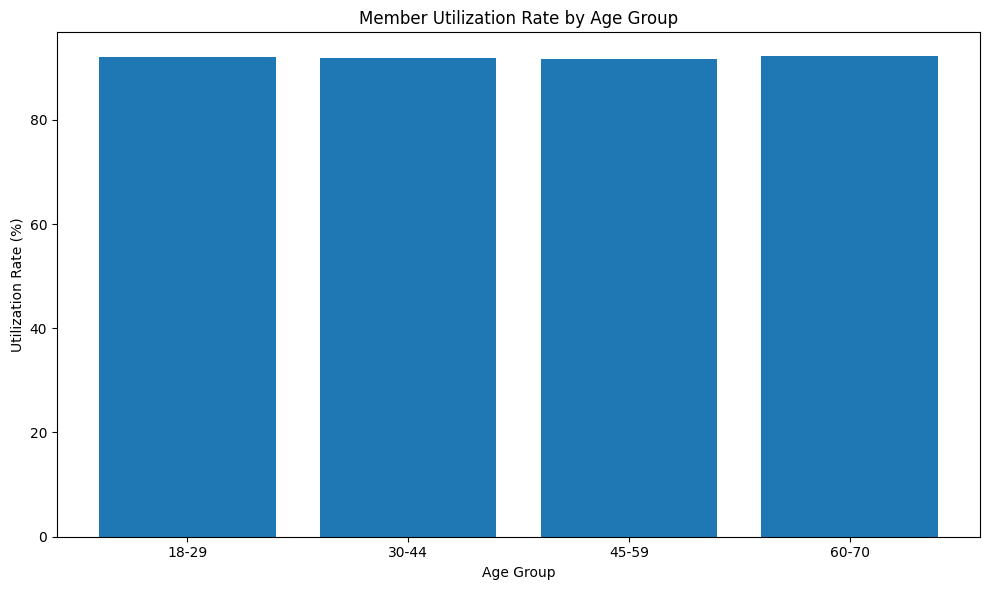

In [64]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_analysis["Age_Group"].astype(str),
    age_analysis["Utilization_Rate"]
)

plt.title("Member Utilization Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Utilization Rate (%)")

plt.tight_layout()
plt.show()

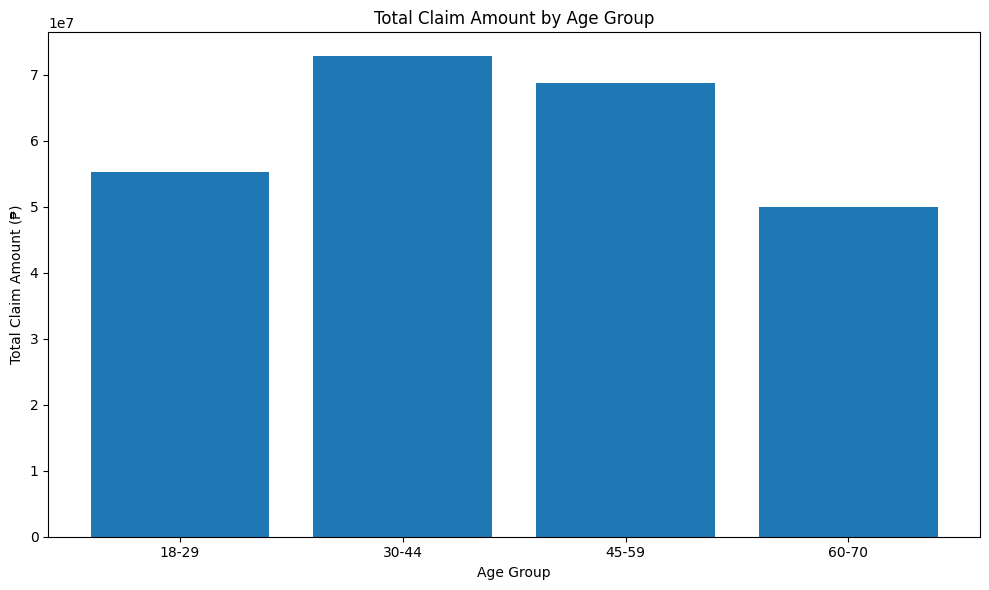

In [65]:
plt.figure(figsize=(10, 6))

plt.bar(
    age_analysis["Age_Group"].astype(str),
    age_analysis["Total_Claim_Amount"]
)

plt.title("Total Claim Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Claim Amount (₱)")

plt.tight_layout()
plt.show()

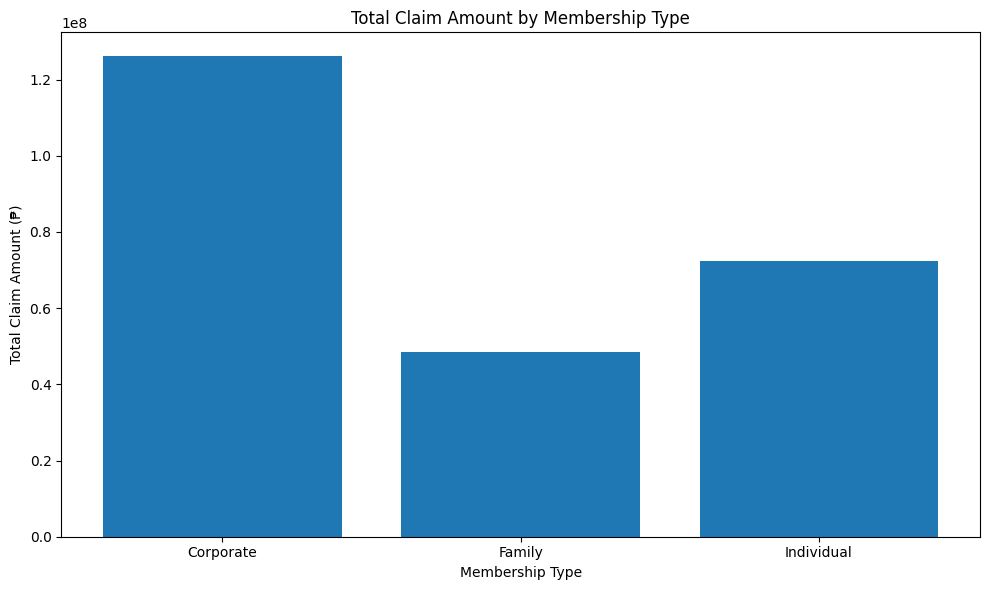

In [66]:
plt.figure(figsize=(10, 6))

plt.bar(
    membership_analysis["Membership_Type"],
    membership_analysis["Total_Claim_Amount"]
)

plt.title("Total Claim Amount by Membership Type")
plt.xlabel("Membership Type")
plt.ylabel("Total Claim Amount (₱)")

plt.tight_layout()
plt.show()

### Key Findings

- Member utilization rates were relatively consistent across age groups, ranging from 91.71% to 92.17%, indicating similar levels of claim participation across the age categories.
- The 30-44 age group recorded the highest total claim amount at approximately ₱72.76 million, followed by the 45-59 age group at approximately ₱68.78 million.
- Female and male members had very similar utilization rates at approximately 91.94% and 91.90%, respectively. Female members recorded a higher total claim amount, consistent with their larger member population in the dataset.
- NCR recorded the highest utilization rate at approximately 92.38% and the highest total claim amount at approximately ₱88.43 million among the four regions.
- Corporate members generated the highest total claim amount at approximately ₱126.08 million and accounted for the largest member group in the dataset.
- Differences in total claim spending should be interpreted together with the size of each member group, since larger populations naturally generate more claims and may result in higher aggregate spending.

### Business Implication

Member analytics should consider both utilization rates and total claim
amounts when comparing demographic and membership groups. Aggregate claim
spending alone may reflect differences in population size rather than
differences in individual healthcare utilization or claim severity.

## 8. Claims Status and Operational Analysis

This analysis examines claim outcomes and operational processing
performance across claim statuses and healthcare service types.

The analysis compares approval, denial, and pending claims by volume
and claim amount, and examines differences in processing time and
claim outcomes across service categories.

In [67]:
status_analysis = (
    claims
    .groupby("Claim_Status")
    .agg(
        Claim_Count=("Claim_ID", "count"),
        Total_Claim_Amount=("Claim_Amount", "sum"),
        Average_Claim_Amount=("Claim_Amount", "mean"),
        Average_Processing_Days=("Processing_Days", "mean")
    )
    .reset_index()
)

status_analysis["Claim_Share"] = (
    status_analysis["Claim_Count"]
    / status_analysis["Claim_Count"].sum()
    * 100
)

status_analysis

,Claim_Status,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Processing_Days,Claim_Share
0,Approved,44077,2.178731e+08,4943.010733,5.502144,88.154
1,Denied,3440,1.725648e+07,5016.417334,5.483721,6.880
2,Pending,2483,1.167726e+07,4702.882429,5.428514,4.966


In [68]:
service_status = pd.crosstab(
    claims["Service_Type"],
    claims["Claim_Status"]
)

service_status

Claim_Status,Approved,Denied,Pending
Service_Type,,,
Diagnostic,5732,455,305
Emergency,6555,521,351
Inpatient,5330,417,287
Laboratory,6683,515,412
Outpatient,15308,1196,884
Pharmacy,4469,336,244


In [69]:
service_status_pct = pd.crosstab(
    claims["Service_Type"],
    claims["Claim_Status"],
    normalize="index"
) * 100

service_status_pct

Claim_Status,Approved,Denied,Pending
Service_Type,,,
Diagnostic,88.293284,7.008626,4.698090
Emergency,88.259055,7.014945,4.726000
Inpatient,88.332781,6.910839,4.756381
Laboratory,87.818660,6.767411,5.413929
Outpatient,88.037727,6.878307,5.083966
Pharmacy,88.512577,6.654783,4.832640


In [70]:
approval_by_service = (
    claims
    .assign(
        Approved_Flag=(
            claims["Claim_Status"] == "Approved"
        ).astype(int)
    )
    .groupby("Service_Type")
    .agg(
        Claim_Count=("Claim_ID", "count"),
        Approval_Rate=("Approved_Flag", "mean")
    )
    .reset_index()
)

approval_by_service["Approval_Rate"] = (
    approval_by_service["Approval_Rate"] * 100
)

approval_by_service = approval_by_service.sort_values(
    "Approval_Rate",
    ascending=False
)

approval_by_service

,Service_Type,Claim_Count,Approval_Rate
5,Pharmacy,5049,88.512577
2,Inpatient,6034,88.332781
0,Diagnostic,6492,88.293284
1,Emergency,7427,88.259055
4,Outpatient,17388,88.037727
3,Laboratory,7610,87.818660


In [71]:
denial_by_service = (
    claims
    .assign(
        Denied_Flag=(
            claims["Claim_Status"] == "Denied"
        ).astype(int)
    )
    .groupby("Service_Type")
    .agg(
        Claim_Count=("Claim_ID", "count"),
        Denial_Rate=("Denied_Flag", "mean")
    )
    .reset_index()
)

denial_by_service["Denial_Rate"] = (
    denial_by_service["Denial_Rate"] * 100
)

denial_by_service = denial_by_service.sort_values(
    "Denial_Rate",
    ascending=False
)

denial_by_service

,Service_Type,Claim_Count,Denial_Rate
1,Emergency,7427,7.014945
0,Diagnostic,6492,7.008626
2,Inpatient,6034,6.910839
4,Outpatient,17388,6.878307
3,Laboratory,7610,6.767411
5,Pharmacy,5049,6.654783


In [72]:
processing_by_status = (
    claims
    .groupby("Claim_Status")
    .agg(
        Average_Processing_Days=("Processing_Days", "mean"),
        Median_Processing_Days=("Processing_Days", "median"),
        Maximum_Processing_Days=("Processing_Days", "max")
    )
    .reset_index()
)

processing_by_status

,Claim_Status,Average_Processing_Days,Median_Processing_Days,Maximum_Processing_Days
0,Approved,5.502144,5.0,10
1,Denied,5.483721,5.0,10
2,Pending,5.428514,5.0,10


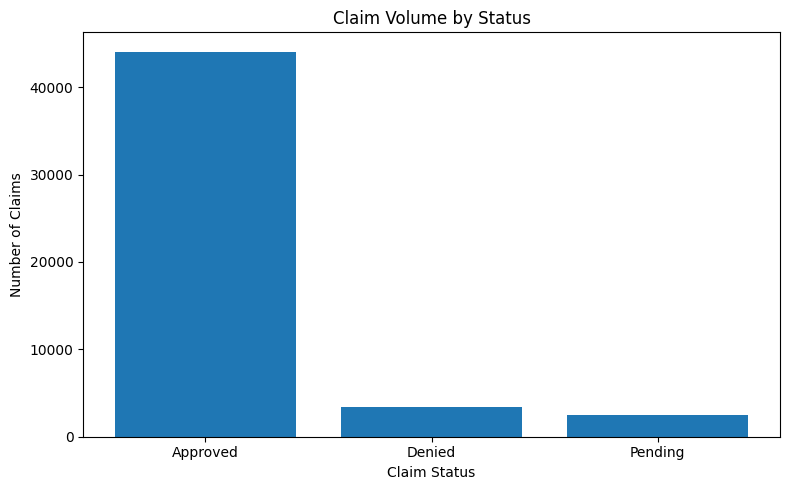

In [73]:
plt.figure(figsize=(8, 5))

plt.bar(
    status_analysis["Claim_Status"],
    status_analysis["Claim_Count"]
)

plt.title("Claim Volume by Status")
plt.xlabel("Claim Status")
plt.ylabel("Number of Claims")

plt.tight_layout()
plt.show()

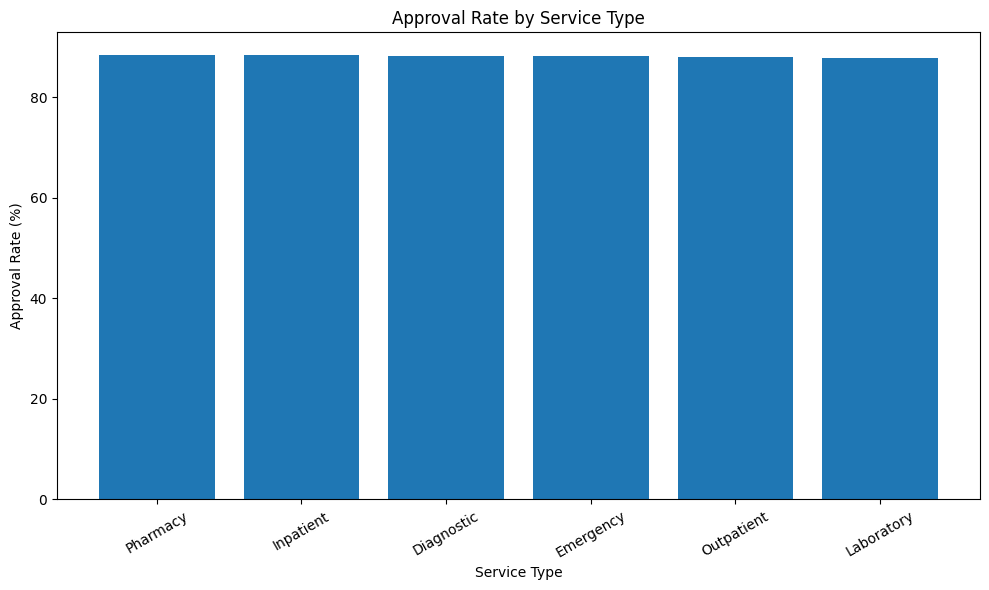

In [74]:
plt.figure(figsize=(10, 6))

plt.bar(
    approval_by_service["Service_Type"],
    approval_by_service["Approval_Rate"]
)

plt.title("Approval Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

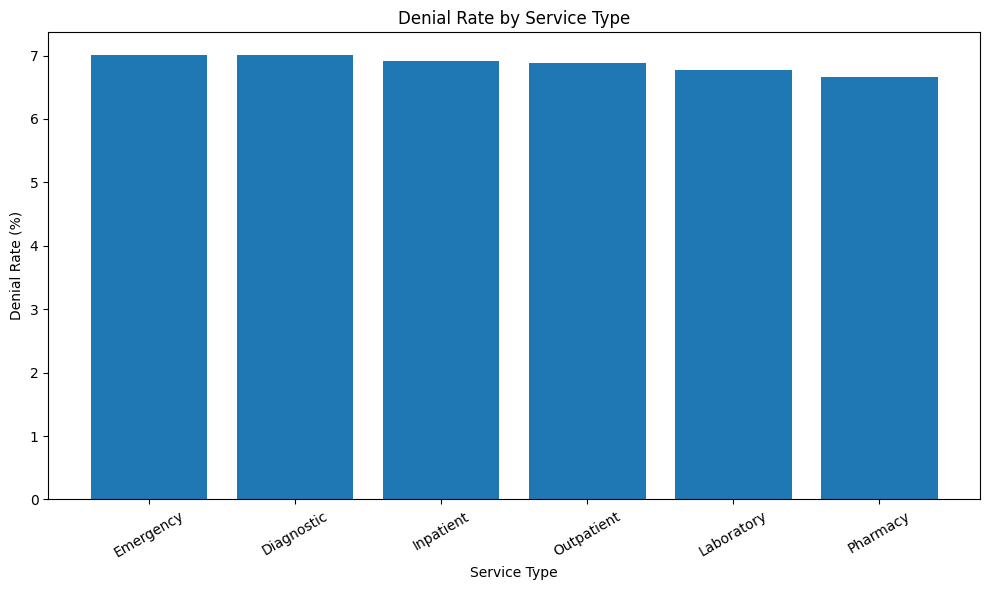

In [75]:
plt.figure(figsize=(10, 6))

plt.bar(
    denial_by_service["Service_Type"],
    denial_by_service["Denial_Rate"]
)

plt.title("Denial Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Denial Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

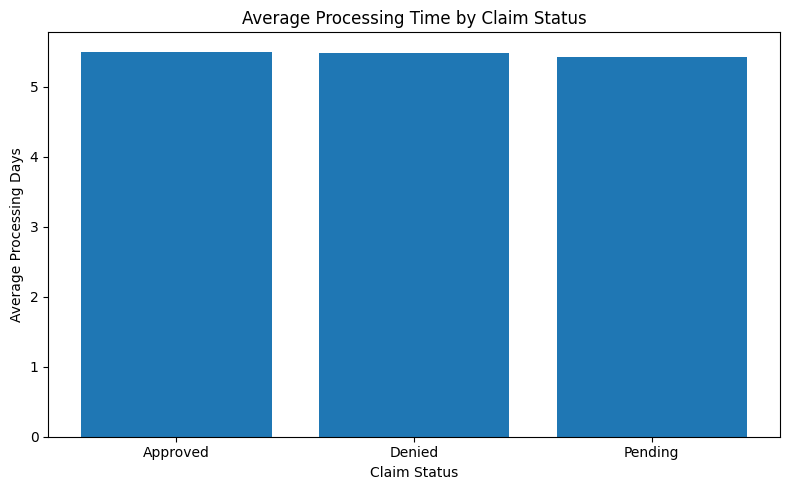

In [76]:
plt.figure(figsize=(8, 5))

plt.bar(
    processing_by_status["Claim_Status"],
    processing_by_status["Average_Processing_Days"]
)

plt.title("Average Processing Time by Claim Status")
plt.xlabel("Claim Status")
plt.ylabel("Average Processing Days")

plt.tight_layout()
plt.show()

### Key Findings

#### Claim Status

- Approved claims accounted for 44,077 claims (88.15%), with approximately ₱217.87 million in total claim amounts.
- Denied claims accounted for 3,440 claims (6.88%), totaling approximately ₱17.26 million.
- Pending claims accounted for 2,483 claims (4.97%), totaling approximately ₱11.68 million.
- Average claim amounts were approximately ₱4,943 for approved claims, ₱5,016 for denied claims, and ₱4,703 for pending claims.

#### Approval and Denial by Service Type

- Approval rates were relatively similar across service types, ranging from 87.82% for Laboratory to 88.51% for Pharmacy.
- Emergency services recorded the highest denial rate at approximately 7.01%.
- Pharmacy recorded the lowest denial rate at approximately 6.65%.
- Differences in approval and denial rates across service types were relatively small in this simulated dataset.

#### Processing Time

- Average processing time was approximately 5.50 days for approved claims, 5.48 days for denied claims, and 5.43 days for pending claims.
- The median processing time was 5 days across all claim statuses.
- The maximum processing time was 10 days across all claim statuses.
- Processing times showed relatively small differences across claim statuses.

### Business Implication

Monitoring claim status, approval rates, denial rates, and processing time
provides an operational view of the claims process. In this dataset,
approval and denial rates were relatively consistent across service types,
while processing times showed limited variation by claim status.

For operational monitoring, these metrics can be incorporated into an HMO
dashboard to track claim outcomes and identify changes in processing
patterns over time.

## 9. High-Cost Claims Analysis

This analysis examines the concentration of healthcare spending among
high-value claims.

High-cost claims are identified using a percentile-based threshold.
The analysis measures the number and financial contribution of these
claims and examines their distribution across service types and providers.

This provides an additional view of claim cost concentration and helps
identify areas that may warrant closer monitoring.

In [77]:
high_cost_threshold = claims["Claim_Amount"].quantile(0.95)

print(
    f"95th percentile claim amount: ₱{high_cost_threshold:,.2f}"
)

95th percentile claim amount: ₱16,878.53


In [78]:
claims["High_Cost_Flag"] = (
    claims["Claim_Amount"] >= high_cost_threshold
)

claims["High_Cost_Flag"].value_counts()

,count
High_Cost_Flag,
False,47500
True,2500


In [79]:
high_cost_summary = pd.DataFrame({
    "Metric": [
        "Total Claims",
        "High-Cost Claims",
        "High-Cost Claim Share",
        "Total Claim Amount",
        "High-Cost Claim Amount",
        "High-Cost Spending Share"
    ],
    "Value": [
        len(claims),
        claims["High_Cost_Flag"].sum(),
        claims["High_Cost_Flag"].mean() * 100,
        claims["Claim_Amount"].sum(),
        claims.loc[
            claims["High_Cost_Flag"],
            "Claim_Amount"
        ].sum(),
        (
            claims.loc[
                claims["High_Cost_Flag"],
                "Claim_Amount"
            ].sum()
            / claims["Claim_Amount"].sum()
            * 100
        )
    ]
})

high_cost_summary

,Metric,Value
0,Total Claims,5.000000e+04
1,High-Cost Claims,2.500000e+03
2,High-Cost Claim Share,5.000000e+00
3,Total Claim Amount,2.468068e+08
4,High-Cost Claim Amount,5.927872e+07
5,High-Cost Spending Share,2.401827e+01


In [80]:
high_cost_average = (
    claims.loc[
        claims["High_Cost_Flag"],
        "Claim_Amount"
    ].mean()
)

regular_claim_average = (
    claims.loc[
        ~claims["High_Cost_Flag"],
        "Claim_Amount"
    ].mean()
)

print(
    f"Average high-cost claim: ₱{high_cost_average:,.2f}"
)

print(
    f"Average regular claim: ₱{regular_claim_average:,.2f}"
)

Average high-cost claim: ₱23,711.49
Average regular claim: ₱3,947.96


In [84]:
high_cost_service = (
    claims[claims["High_Cost_Flag"]]
    .groupby("Service_Type")
    .agg(
        High_Cost_Claims=("Claim_ID", "count"),
        High_Cost_Amount=("Claim_Amount", "sum"),
        Average_High_Cost_Claim=("Claim_Amount", "mean")
    )
    .reset_index()
    .sort_values(
        "High_Cost_Amount",
        ascending=False
    )
)

high_cost_service

,Service_Type,High_Cost_Claims,High_Cost_Amount,Average_High_Cost_Claim
2,Inpatient,2366,56572713.19,23910.698728
1,Emergency,127,2560598.57,20162.193465
0,Diagnostic,7,145407.83,20772.547143


In [88]:
high_cost_provider = (
    claims[claims["High_Cost_Flag"]]
    .groupby("Provider")
    .agg(
        High_Cost_Claims=("Claim_ID", "count"),
        High_Cost_Amount=("Claim_Amount", "sum"),
        Average_High_Cost_Claim=("Claim_Amount", "mean")
    )
    .reset_index()
    .sort_values(
        "High_Cost_Amount",
        ascending=False
    )
)

high_cost_provider

,Provider,High_Cost_Claims,High_Cost_Amount,Average_High_Cost_Claim
1,Provider B,345,8421954.29,24411.461710
6,Provider G,334,7854918.04,23517.718683
0,Provider A,325,7691043.38,23664.748862
4,Provider E,314,7467452.03,23781.694363
3,Provider D,304,7303547.75,24024.828125
7,Provider H,301,7073138.64,23498.799468
5,Provider F,291,6801454.70,23372.696564
2,Provider C,286,6665210.76,23304.932727


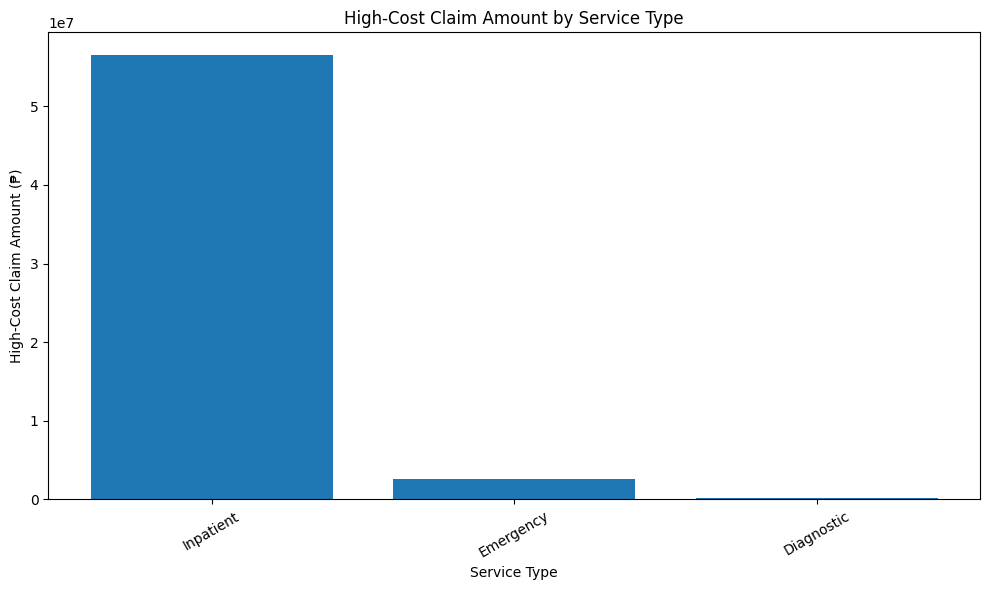

In [89]:
plt.figure(figsize=(10, 6))

plt.bar(
    high_cost_service["Service_Type"],
    high_cost_service["High_Cost_Amount"]
)

plt.title("High-Cost Claim Amount by Service Type")
plt.xlabel("Service Type")
plt.ylabel("High-Cost Claim Amount (₱)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

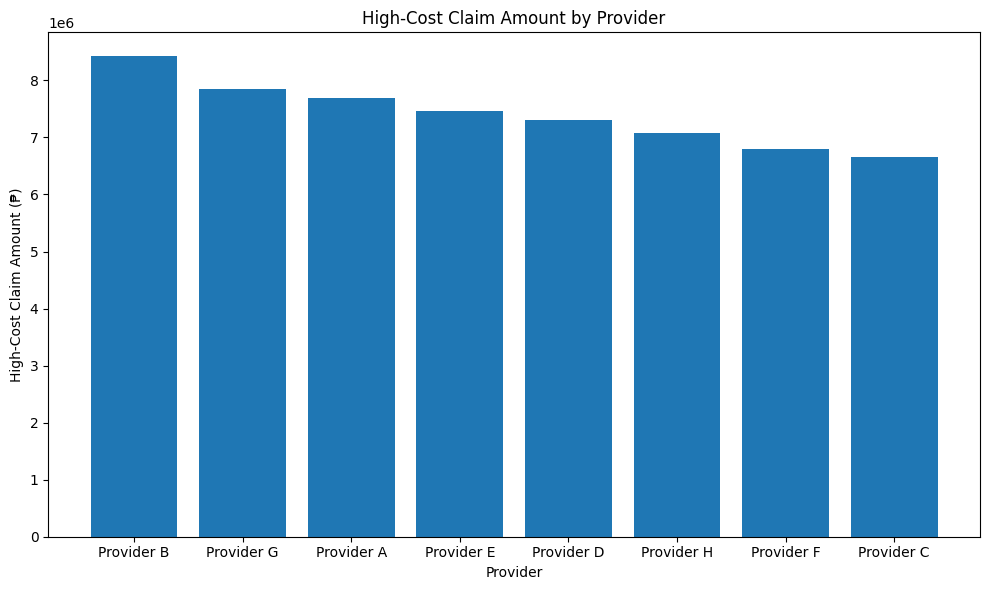

In [90]:
plt.figure(figsize=(10, 6))

plt.bar(
    high_cost_provider["Provider"],
    high_cost_provider["High_Cost_Amount"]
)

plt.title("High-Cost Claim Amount by Provider")
plt.xlabel("Provider")
plt.ylabel("High-Cost Claim Amount (₱)")

plt.tight_layout()
plt.show()

In [91]:
top_high_cost_claims = (
    claims
    .sort_values(
        "Claim_Amount",
        ascending=False
    )
    [
        [
            "Claim_ID",
            "Member_ID",
            "Service_Type",
            "Provider",
            "Claim_Amount",
            "Claim_Status",
            "Processing_Days"
        ]
    ]
    .head(10)
)

top_high_cost_claims

,Claim_ID,Member_ID,Service_Type,Provider,Claim_Amount,Claim_Status,Processing_Days
27041,C0027042,M008653,Inpatient,Provider B,77322.71,Denied,5
7030,C0007031,M019534,Inpatient,Provider B,71306.94,Approved,9
30589,C0030590,M001637,Inpatient,Provider H,71116.73,Approved,8
16371,C0016372,M001580,Inpatient,Provider E,67159.62,Approved,1
15220,C0015221,M012438,Inpatient,Provider C,61950.86,Approved,4
44349,C0044350,M011026,Inpatient,Provider E,61785.00,Approved,10
27501,C0027502,M009585,Inpatient,Provider H,59583.87,Approved,10
34450,C0034451,M011231,Inpatient,Provider G,59364.61,Approved,5
17840,C0017841,M016360,Inpatient,Provider B,57230.04,Approved,4
19445,C0019446,M007911,Inpatient,Provider F,56940.24,Approved,2


### Key Findings

- High-cost claims were defined as the top 5% of claims based on claim amount. Of the 50,000 claims analyzed, 2,500 were classified as high-cost.
- High-cost claims represented 5.00% of all claims but accounted for approximately ₱59.28 million, or 24.02% of total claim spending.
- The average high-cost claim was approximately ₱23,711, compared with approximately ₱3,948 for regular claims.
- Inpatient services accounted for 2,366 of the 2,500 high-cost claims and approximately ₱56.57 million in high-cost claim spending.
- Emergency services accounted for 127 high-cost claims, while Diagnostic services accounted for 7.
- Provider B recorded the highest high-cost claim amount at approximately ₱8.42 million, followed by Provider G at approximately ₱7.85 million and Provider A at approximately ₱7.69 million.
- The highest individual claim was approximately ₱77,323. It was an inpatient claim from Provider B and was recorded as denied.

### Business Implication

High-cost claims represent a relatively small proportion of claim volume
but contribute substantially to overall healthcare spending. Monitoring
high-value claims separately from overall claim volume can therefore
provide additional insight into cost concentration.

The concentration of high-cost claims in inpatient services suggests that
inpatient utilization is an important area for further monitoring in this
dataset. However, the analysis is descriptive and does not establish the
underlying causes of high claim costs.

## 10. SQL Analysis

SQL is used to demonstrate relational data querying and business-oriented
data extraction.

The analysis recreates selected HMO business questions using SQL,
including claim status, service type, provider performance, monthly
claim trends, and member-level claim spending.

SQLite is used as the SQL environment for this project.

In [94]:
import sqlite3

# Create an in-memory SQLite database
conn = sqlite3.connect(":memory:")

# Create SQL-ready copies
claims_sql = claims.copy()
members_sql = members.copy()

# Convert pandas Period columns to text for SQLite
for col in claims_sql.columns:
    if str(claims_sql[col].dtype) == "period[M]":
        claims_sql[col] = claims_sql[col].astype(str)

# Load the datasets into SQL tables
claims_sql.to_sql(
    "claims",
    conn,
    index=False,
    if_exists="replace"
)

members_sql.to_sql(
    "members",
    conn,
    index=False,
    if_exists="replace"
)

print("SQL database created successfully.")

SQL database created successfully.


In [95]:
claims_table_check = pd.read_sql_query(
    """
    SELECT *
    FROM claims
    LIMIT 5
    """,
    conn
)

claims_table_check

,Claim_ID,Member_ID,Claim_Date,Service_Type,Provider,Claim_Amount,Claim_Status,Processing_Days,Claim_Month,High_Cost_Flag
0,C0000001,M008691,2025-05-22 00:00:00,Outpatient,Provider D,3640.17,Approved,2,2025-05,0
1,C0000002,M005656,2025-05-21 00:00:00,Emergency,Provider C,13846.77,Approved,2,2025-05,0
2,C0000003,M007794,2025-10-25 00:00:00,Outpatient,Provider H,2436.07,Approved,6,2025-10,0
3,C0000004,M015819,2025-08-04 00:00:00,Pharmacy,Provider G,2956.16,Approved,7,2025-08,0
4,C0000005,M013920,2025-09-26 00:00:00,Diagnostic,Provider H,6962.64,Approved,6,2025-09,0


### SQL Query 1 — Claims by Status

This query summarizes healthcare claims by their current status.

The analysis calculates the number of claims, total claim amount, and
average claim amount for approved, denied, and pending claims.

This provides a basic overview of claim outcomes and demonstrates the use
of SQL aggregation functions such as COUNT(), SUM(), and AVG(), together
with GROUP BY and ORDER BY.

In [96]:
claims_by_status_sql = pd.read_sql_query(
    """
    SELECT
        Claim_Status,
        COUNT(*) AS Claim_Count,
        SUM(Claim_Amount) AS Total_Claim_Amount,
        AVG(Claim_Amount) AS Average_Claim_Amount
    FROM claims
    GROUP BY Claim_Status
    ORDER BY Claim_Count DESC
    """,
    conn
)

claims_by_status_sql

,Claim_Status,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,Approved,44077,2.178731e+08,4943.010733
1,Denied,3440,1.725648e+07,5016.417334
2,Pending,2483,1.167726e+07,4702.882429


### Query 1 Findings

The SQL query identified 44,077 approved claims, 3,440 denied claims,
and 2,483 pending claims. Approved claims represented the largest share
of claim volume and claim spending.

The SQL results are consistent with the earlier Python-based claims
status analysis, demonstrating that the same business result can be
obtained using SQL.

### SQL Query 2 — Service Type Analysis

This query examines claim volume, total claim spending, and average claim
amount across healthcare service types.

The objective is to identify which service categories contribute most to
overall claim activity and healthcare spending.

In [97]:
service_sql = pd.read_sql_query(
    """
    SELECT
        Service_Type,
        COUNT(*) AS Claim_Count,
        SUM(Claim_Amount) AS Total_Claim_Amount,
        AVG(Claim_Amount) AS Average_Claim_Amount
    FROM claims
    GROUP BY Service_Type
    ORDER BY Total_Claim_Amount DESC
    """,
    conn
)

service_sql

,Service_Type,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,Inpatient,6034,99641122.21,16513.278457
1,Emergency,7427,53254579.22,7170.402480
2,Outpatient,17388,34630629.36,1991.639600
3,Diagnostic,6492,32423103.67,4994.316647
4,Laboratory,7610,18474449.95,2427.654396
5,Pharmacy,5049,8382932.36,1660.315381


### Query 2 Findings

Inpatient services recorded the highest total claim amount at approximately
₱99.64 million, despite having fewer claims than outpatient services.

Outpatient services had the highest claim volume with 17,388 claims but
accounted for approximately ₱34.63 million in total claim spending.

Emergency services recorded the second-highest total claim amount at
approximately ₱53.25 million and had an average claim amount of
approximately ₱7,170.

The results demonstrate that claim frequency and financial impact can
differ substantially across service types. SQL aggregation successfully
reproduced the service-level findings from the Python analysis.

### SQL Query 3 — Provider Performance

This query summarizes provider-level claim activity by calculating claim
volume, total claim spending, average claim amount, and average processing
time.

The analysis demonstrates how SQL can be used to compare financial and
operational measures across healthcare providers.

In [98]:
provider_sql = pd.read_sql_query(
    """
    SELECT
        Provider,
        COUNT(*) AS Claim_Count,
        SUM(Claim_Amount) AS Total_Claim_Amount,
        AVG(Claim_Amount) AS Average_Claim_Amount,
        AVG(Processing_Days) AS Average_Processing_Days
    FROM claims
    GROUP BY Provider
    ORDER BY Total_Claim_Amount DESC
    """,
    conn
)

provider_sql

,Provider,Claim_Count,Total_Claim_Amount,Average_Claim_Amount,Average_Processing_Days
0,Provider A,6321,31624858.40,5003.141655,5.482519
1,Provider B,6247,31197153.37,4993.941631,5.484393
2,Provider G,6249,31153715.94,4985.392213,5.538486
3,Provider H,6395,30948041.77,4839.412317,5.538858
4,Provider E,6219,30685718.87,4934.188595,5.466474
5,Provider C,6285,30450126.01,4844.888784,5.482578
6,Provider F,6170,30404083.61,4927.728300,5.490113
7,Provider D,6114,30343118.80,4962.891528,5.493294


### Query 3 Findings

Provider A recorded the highest total claim amount at approximately
₱31.62 million, based on 6,321 claims.

Provider B recorded the second-highest total claim amount at approximately
₱31.20 million, while Provider G recorded approximately ₱31.15 million.

Provider H had the highest claim volume with 6,395 claims, while Provider D
had the lowest claim volume with 6,114 claims.

Average claim amounts were relatively similar across providers, ranging
from approximately ₱4,840 to ₱5,003.

Average processing times were also relatively consistent, ranging from
approximately 5.47 to 5.54 days.

### SQL Query 4 — Monthly Claims Trend

This query aggregates claims by month to examine changes in claim volume,
total claim spending, and average claim amount over time.

Monthly aggregation allows trends in healthcare utilization and spending
to be monitored using SQL.

In [99]:
monthly_sql = pd.read_sql_query(
    """
    SELECT
        strftime('%Y-%m', Claim_Date) AS Claim_Month,
        COUNT(*) AS Claim_Count,
        SUM(Claim_Amount) AS Total_Claim_Amount,
        AVG(Claim_Amount) AS Average_Claim_Amount
    FROM claims
    GROUP BY strftime('%Y-%m', Claim_Date)
    ORDER BY Claim_Month
    """,
    conn
)

monthly_sql

,Claim_Month,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,2025-01,4276,20793750.73,4862.897739
1,2025-02,3808,18471197.20,4850.629517
2,2025-03,4212,20652212.50,4903.184354
3,2025-04,4126,20839071.54,5050.671726
4,2025-05,4230,20872340.13,4934.359369
5,2025-06,4120,19900944.68,4830.326379
6,2025-07,4272,20960118.75,4906.394838
7,2025-08,4292,21129520.03,4923.000939
8,2025-09,4077,20050096.20,4917.855335
9,2025-10,4270,21667698.41,5074.402438


### Query 4 Findings

Monthly claim volume varied throughout 2025, with the highest claim volume
recorded in January at 4,276 claims and the lowest in February at 3,808
claims.

Total claim spending was highest in October at approximately ₱21.67 million
and lowest in February at approximately ₱18.47 million.

The average claim amount was highest in October at approximately ₱5,074.40
and lowest in June at approximately ₱4,830.33.

The monthly results demonstrate that changes in claim volume and total
claim spending do not always move together, highlighting the importance
of monitoring both utilization and claim value.

### SQL Query 5 — Member-Level Claim Spending

This query combines the claims and members tables using Member_ID to
identify members with the highest total claim spending.

Member demographic and membership characteristics are included to
demonstrate how relational data can be combined for business analysis.

In [100]:
member_sql = pd.read_sql_query(
    """
    SELECT
        c.Member_ID,
        m.Gender,
        m.Region,
        m.Membership_Type,
        COUNT(c.Claim_ID) AS Claim_Count,
        SUM(c.Claim_Amount) AS Total_Claim_Amount,
        AVG(c.Claim_Amount) AS Average_Claim_Amount
    FROM claims AS c
    LEFT JOIN members AS m
        ON c.Member_ID = m.Member_ID
    GROUP BY
        c.Member_ID,
        m.Gender,
        m.Region,
        m.Membership_Type
    ORDER BY Total_Claim_Amount DESC
    LIMIT 10
    """,
    conn
)

member_sql

,Member_ID,Gender,Region,Membership_Type,Claim_Count,Total_Claim_Amount,Average_Claim_Amount
0,M018406,Female,Visayas,Individual,5,107637.54,21527.508000
1,M012684,Female,Visayas,Individual,6,107206.14,17867.690000
2,M000676,Female,Mindanao,Individual,7,98103.28,14014.754286
3,M000579,Female,Luzon,Family,7,94895.99,13556.570000
4,M011399,Female,NCR,Individual,6,94474.47,15745.745000
5,M011026,Female,Luzon,Corporate,3,91585.80,30528.600000
6,M011940,Female,NCR,Corporate,6,91396.65,15232.775000
7,M001580,Male,Luzon,Family,3,87613.28,29204.426667
8,M019534,Male,NCR,Individual,5,87083.16,17416.632000
9,M011231,Male,Visayas,Individual,3,86465.12,28821.706667


### Query 5 Findings

The SQL query identified the top 10 members by total claim spending by
combining claim records with member demographic and membership information.

The member with the highest total claim spending was M018406, with
approximately ₱107,638 across 5 claims.

Several high-spending members had relatively few claims but high average
claim amounts. For example, M011026 recorded 3 claims with an average
claim amount of approximately ₱30,529.

The results demonstrate how joining claims and member-level information
can provide additional context for analyzing healthcare utilization and
claim spending.

### SQL Query 6 — High-Cost Claims

This query identifies high-cost claims using the 95th-percentile
claim amount threshold calculated during the Python analysis.

The analysis examines the number, total amount, and average amount of
high-cost claims across healthcare service types.

In [101]:
print(
    f"High-cost threshold: ₱{high_cost_threshold:,.2f}"
)

High-cost threshold: ₱16,878.53


In [102]:
high_cost_sql = pd.read_sql_query(
    f"""
    SELECT
        Service_Type,
        COUNT(*) AS High_Cost_Claims,
        SUM(Claim_Amount) AS High_Cost_Amount,
        AVG(Claim_Amount) AS Average_High_Cost_Claim
    FROM claims
    WHERE Claim_Amount >= {high_cost_threshold}
    GROUP BY Service_Type
    ORDER BY High_Cost_Amount DESC
    """,
    conn
)

high_cost_sql

,Service_Type,High_Cost_Claims,High_Cost_Amount,Average_High_Cost_Claim
0,Inpatient,2366,56572713.19,23910.698728
1,Emergency,127,2560598.57,20162.193465
2,Diagnostic,7,145407.83,20772.547143


### Query 6 Findings

The 95th-percentile claim amount was ₱16,878.53 and was used as the
threshold for identifying high-cost claims.

Inpatient services accounted for the largest concentration of high-cost
claims, with 2,366 claims totaling approximately ₱56.57 million.

Emergency services recorded 127 high-cost claims totaling approximately
₱2.56 million, while Diagnostic services recorded 7 high-cost claims
totaling approximately ₱145,408.

The SQL results are consistent with the Python high-cost claim analysis,
confirming that inpatient services account for the majority of high-value
claims in this dataset.

### SQL Query 7 — High-Cost Claims by Provider

This query examines how high-cost claims are distributed across healthcare
providers.

The analysis calculates the number of high-cost claims, total high-cost
claim amount, and average high-cost claim amount for each provider.

In [103]:
high_cost_provider_sql = pd.read_sql_query(
    f"""
    SELECT
        Provider,
        COUNT(*) AS High_Cost_Claims,
        SUM(Claim_Amount) AS High_Cost_Amount,
        AVG(Claim_Amount) AS Average_High_Cost_Claim
    FROM claims
    WHERE Claim_Amount >= {high_cost_threshold}
    GROUP BY Provider
    ORDER BY High_Cost_Amount DESC
    """,
    conn
)

high_cost_provider_sql

,Provider,High_Cost_Claims,High_Cost_Amount,Average_High_Cost_Claim
0,Provider B,345,8421954.29,24411.461710
1,Provider G,334,7854918.04,23517.718683
2,Provider A,325,7691043.38,23664.748862
3,Provider E,314,7467452.03,23781.694363
4,Provider D,304,7303547.75,24024.828125
5,Provider H,301,7073138.64,23498.799468
6,Provider F,291,6801454.70,23372.696564
7,Provider C,286,6665210.76,23304.932727


### Query 7 Findings

Provider B recorded the highest number of high-cost claims with 345 claims,
representing approximately ₱8.42 million in high-cost claim spending.

Provider G ranked next with 334 high-cost claims totaling approximately
₱7.85 million, followed by Provider A with 325 high-cost claims totaling
approximately ₱7.69 million.

The distribution of high-cost claim spending was relatively spread across
providers, with high-cost claim amounts ranging from approximately
₱6.67 million to ₱8.42 million.

These results provide a provider-level view of high-value claims and can
support monitoring of cost concentration across healthcare providers.

### SQL Query 8 — Approval Rate by Service Type

This query calculates the approval rate for each healthcare service type
using conditional aggregation.

The analysis compares claim outcomes across service categories and
demonstrates the use of CASE WHEN in SQL.

In [104]:
approval_sql = pd.read_sql_query(
    """
    SELECT
        Service_Type,
        COUNT(*) AS Claim_Count,
        SUM(
            CASE
                WHEN Claim_Status = 'Approved' THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*) AS Approval_Rate
    FROM claims
    GROUP BY Service_Type
    ORDER BY Approval_Rate DESC
    """,
    conn
)

approval_sql

,Service_Type,Claim_Count,Approval_Rate
0,Pharmacy,5049,88.512577
1,Inpatient,6034,88.332781
2,Diagnostic,6492,88.293284
3,Emergency,7427,88.259055
4,Outpatient,17388,88.037727
5,Laboratory,7610,87.818660


### Query 8 Findings

Pharmacy recorded the highest approval rate at approximately 88.51%,
followed by Inpatient at 88.33% and Diagnostic at 88.29%.

Laboratory recorded the lowest approval rate at approximately 87.82%,
followed by Outpatient at 88.04%.

Overall, approval rates were relatively consistent across service types,
with a difference of less than one percentage point between the highest
and lowest service-level approval rates.

The analysis demonstrates how SQL conditional aggregation using CASE WHEN
can be used to calculate operational performance metrics.

### SQL Query 9 — Denial Rate by Service Type

This query calculates the percentage of claims denied for each healthcare
service type.

The result provides an additional view of claim outcomes and demonstrates
how conditional aggregation can be used to monitor denial patterns across
service categories.

In [105]:
denial_sql = pd.read_sql_query(
    """
    SELECT
        Service_Type,
        COUNT(*) AS Claim_Count,
        SUM(
            CASE
                WHEN Claim_Status = 'Denied' THEN 1
                ELSE 0
            END
        ) * 100.0 / COUNT(*) AS Denial_Rate
    FROM claims
    GROUP BY Service_Type
    ORDER BY Denial_Rate DESC
    """,
    conn
)

denial_sql

,Service_Type,Claim_Count,Denial_Rate
0,Emergency,7427,7.014945
1,Diagnostic,6492,7.008626
2,Inpatient,6034,6.910839
3,Outpatient,17388,6.878307
4,Laboratory,7610,6.767411
5,Pharmacy,5049,6.654783


### Query 9 Findings

Emergency services recorded the highest denial rate at approximately
7.01%, followed closely by Diagnostic services at 7.01%.

Pharmacy recorded the lowest denial rate at approximately 6.65%, while
Laboratory recorded a denial rate of approximately 6.77%.

Overall, denial rates were relatively consistent across service types,
with the difference between the highest and lowest rates being less than
one percentage point.

The results complement the approval-rate analysis and demonstrate how
conditional aggregation using CASE WHEN can be used to calculate claim
outcome metrics in SQL.

## SQL Analysis Summary

The SQL analysis demonstrated the use of relational data querying to
answer common HMO business questions.

The analysis included claim status, service type, provider performance,
monthly claim trends, member-level spending, high-cost claims, and
service-level approval and denial rates.

The SQL workflow demonstrated the use of:

- SELECT and FROM
- WHERE filtering
- GROUP BY aggregation
- ORDER BY sorting
- COUNT(), SUM(), and AVG()
- CASE WHEN conditional logic
- Date-based aggregation
- LEFT JOIN
- LIMIT
- Business-oriented data extraction

The SQL results were consistent with the corresponding Python analyses,
providing validation that the business metrics were calculated
consistently across analytical tools.

### SQL Skills Demonstrated

This project demonstrates practical SQL skills including:

- Aggregating healthcare claims using COUNT, SUM, and AVG
- Grouping data by claim status, service type, and provider
- Filtering high-cost claims using WHERE
- Calculating approval and denial rates using CASE WHEN
- Aggregating claims by month using date functions
- Combining member and claims data using LEFT JOIN
- Ranking results using ORDER BY
- Extracting top records using LIMIT
- Translating business questions into SQL queries